# Subtask 1: LDC Time-Frequency Visualization

This notebook implements subtask 1 of UCAS 2026 Innovation Practice Task 5 using the real file `LDC2_spritz_mbhb1_training_v1.h5`.

Task requirements checked before implementation:

1. Read LISA Data Challenge gravitational-wave data from the HDF5 file, replacing NaN values with zero.
2. Apply Wilson-Daubechies-Meyer (WDM) wavelet transform.
3. Apply fractional Fourier transform (FRFT).
4. Use `matplotlib.pcolormesh` to visualize transform results clearly enough to show signal features.

Reference code used:

- WDM: `XGI-MSU/WDMWaveletTransforms`, especially `transform_wavelet_freq_time`.
- FRFT: compared `siddharth-maddali/frft`, `nanaln/python_frft`, and `MStamatis/frft2d`; this notebook uses a one-dimensional NumPy/SciPy implementation in `src/frft_utils.py` based on `nanaln/python_frft`, because the LDC TDI channel is a one-dimensional time series.

In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import (
    clean_timeseries,
    crop_by_time,
    crop_to_wdm_shape,
    print_hdf5_tree,
    read_dataset_attrs,
    read_sky_catalog,
    read_tdi_dataset,
    summarize_nan_counts,
    tdi_xyz_to_aet,
)
from src.frft_utils import scan_frft_alpha
from src.plotting import ensure_dir, plot_frequency_diagnostic, plot_pcolormesh, plot_timeseries, save_current_figure

from WDMWaveletTransforms.wavelet_transforms import transform_wavelet_freq_time

DATA_PATH = Path(r'E:\BaiduNetdiskDownload\LDC2_spritz_mbhb1_training_v1.h5')
FIGURE_DIR = ensure_dir(PROJECT_ROOT / 'figures' / 'task5_subtask1')

DATA_PATH.exists(), DATA_PATH

(True, WindowsPath('E:/BaiduNetdiskDownload/LDC2_spritz_mbhb1_training_v1.h5'))

## 1. Inspect the HDF5 Structure

The task explicitly asks us to read the HDF5 data. We first inspect all groups, datasets, shapes, dtypes, and key attributes.

In [2]:
print_hdf5_tree(DATA_PATH)

+ clean/
  - clean/tdi: shape=(535680, 1), dtype=[('t', '<f8'), ('X', '<f8'), ('Y', '<f8'), ('Z', '<f8')]
    @coord: t
    @dt: 5.0
    @t0: 8899200.0
    @units: dimensionless
+ header/
  - header/date: shape=(), dtype=object
+ instru/
  + instru/config/
    - instru/config/LISA_AAFILTER_ATTENUATION: shape=(), dtype=int64
    - instru/config/LISA_AAFILTER_TRANSITION_BAND_0: shape=(), dtype=float64
    - instru/config/LISA_AAFILTER_TRANSITION_BAND_1: shape=(), dtype=float64
    - instru/config/LISA_ACC_NOISE_A_LEVEL: shape=(), dtype=float64
    - instru/config/LISA_ACC_NOISE_F_KNEE: shape=(), dtype=float64
    - instru/config/LISA_ACC_NOISE_USE_PZM: shape=(), dtype=bool
    - instru/config/LISA_ADC_RECURSION_ORDER: shape=(), dtype=int64
    - instru/config/LISA_BACKLINK_NOISE_A_LEVEL: shape=(), dtype=float64
    - instru/config/LISA_BACKLINK_NOISE_F_KNEE: shape=(), dtype=float64
    - instru/config/LISA_DEBUG_CLOCK_OFFSETS: shape=(), dtype=bool
    - instru/config/LISA_FREQUENCY_OFFSE

## 2. Read TDI Channels and Metadata

The file contains compound TDI datasets with fields `t`, `X`, `Y`, and `Z`. The `obs/tdi` data include NaN gaps, so they are counted and then replaced by zero during cleaning. For clearer signal visualization, the main WDM/FRFT figures use the real signal-only `sky/tdi` channel from the same HDF5 file, while `obs/tdi` is also inspected.

In [3]:
obs_tdi = read_tdi_dataset(DATA_PATH, 'obs/tdi')
sky_tdi = read_tdi_dataset(DATA_PATH, 'sky/tdi')
attrs = read_dataset_attrs(DATA_PATH, 'obs/tdi')
catalog = read_sky_catalog(DATA_PATH)

dt = float(attrs['dt'])
time = obs_tdi['t']
coalescence_time = float(catalog['CoalescenceTime'])

summary = {
    'n_samples': len(time),
    'dt_seconds': dt,
    'duration_days': len(time) * dt / 86400,
    't_start': float(time[0]),
    't_end': float(time[-1]),
    'coalescence_time': coalescence_time,
    'coalescence_day_from_start': (coalescence_time - time[0]) / 86400,
    'obs_nan_counts': summarize_nan_counts(obs_tdi),
    'sky_nan_counts': summarize_nan_counts(sky_tdi),
}
summary

{'n_samples': 535680,
 'dt_seconds': 5.0,
 'duration_days': 31.0,
 't_start': 8899200.0,
 't_end': 11577595.0,
 'coalescence_time': 11526944.921879262,
 'coalescence_day_from_start': np.float64(30.413714373602566),
 'obs_nan_counts': {'X': 10080, 'Y': 10080, 'Z': 10080},
 'sky_nan_counts': {'X': 0, 'Y': 0, 'Z': 0}}

## 3. Construct A/E/T-like Channels and Clean NaNs

We keep the original `X/Y/Z` channels and also form standard orthogonal A/E/T-like combinations. The main analysis channel below is `A` from `sky/tdi`, because it shows the MBHB chirp more clearly than the noisy observed stream.

In [4]:
obs_xyz = {key: np.nan_to_num(obs_tdi[key], nan=0.0) for key in ['X', 'Y', 'Z']}
sky_xyz = {key: np.nan_to_num(sky_tdi[key], nan=0.0) for key in ['X', 'Y', 'Z']}

obs_aet = tdi_xyz_to_aet(obs_xyz['X'], obs_xyz['Y'], obs_xyz['Z'])
sky_aet = tdi_xyz_to_aet(sky_xyz['X'], sky_xyz['Y'], sky_xyz['Z'])

analysis_channel = 'A'
analysis_data = clean_timeseries(sky_aet[analysis_channel], normalize=True)
obs_analysis_data = clean_timeseries(obs_aet[analysis_channel], normalize=True)

channel_stats = pd.DataFrame(
    {
        'source': ['obs/tdi A', 'sky/tdi A'],
        'mean_after_cleaning': [float(np.mean(obs_analysis_data)), float(np.mean(analysis_data))],
        'std_after_cleaning': [float(np.std(obs_analysis_data)), float(np.std(analysis_data))],
        'min': [float(np.min(obs_analysis_data)), float(np.min(analysis_data))],
        'max': [float(np.max(obs_analysis_data)), float(np.max(analysis_data))],
    }
)
channel_stats

,source,mean_after_cleaning,std_after_cleaning,min,max
0,obs/tdi A,9.550306e-19,1.0,-259.909302,599.241301
1,sky/tdi A,-1.044953e-19,1.0,-153.257810,159.727349


## 4. Basic Time and Frequency Diagnostics

Before performing WDM/FRFT, plot the chosen channel around the merger and check its power spectrum.

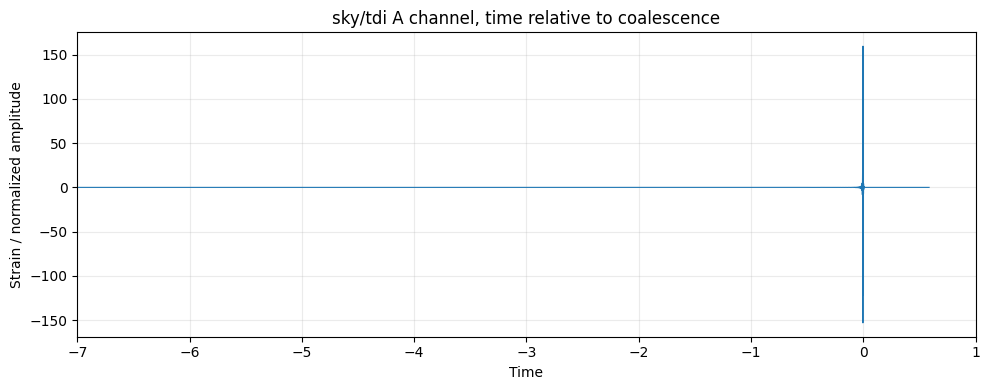

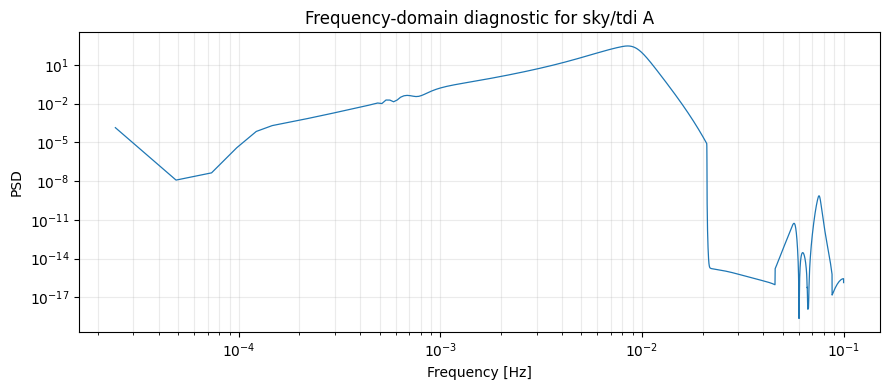

In [5]:
plot_timeseries((time - coalescence_time) / 86400, analysis_data, 'sky/tdi A channel, time relative to coalescence')
plt.xlim(-7, 1)
save_current_figure(FIGURE_DIR / '01_sky_a_timeseries_relative_to_tc.png')
plt.show()

freqs, psd = signal.welch(analysis_data, fs=1 / dt, nperseg=8192)
plot_frequency_diagnostic(freqs[1:], psd[1:], 'Frequency-domain diagnostic for sky/tdi A')
save_current_figure(FIGURE_DIR / '02_sky_a_frequency_diagnostic.png')
plt.show()

## 5. Crop the Analysis Window

The MBHB coalescence occurs near the end of the file. We use a real-data window from 5 days before coalescence to 0.5 days after coalescence. This gives enough inspiral and merger information while keeping the transforms fast and visually clear.

Crop start/end relative to tc [days]: -4.999999095824789 0.49994303380484106
Cropped samples: 95040 duration [days]: 5.5


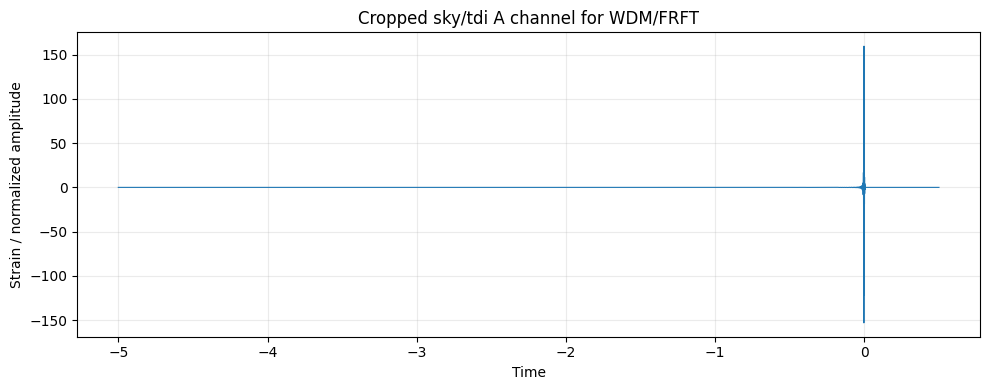

In [6]:
window_start = coalescence_time - 5 * 86400
window_end = min(coalescence_time + 0.5 * 86400, float(time[-1]))
time_crop, data_crop = crop_by_time(time, analysis_data, window_start, window_end)
time_crop_days = (time_crop - coalescence_time) / 86400

print('Crop start/end relative to tc [days]:', time_crop_days[0], time_crop_days[-1])
print('Cropped samples:', len(data_crop), 'duration [days]:', len(data_crop) * dt / 86400)

plot_timeseries(time_crop_days, data_crop, 'Cropped sky/tdi A channel for WDM/FRFT')
save_current_figure(FIGURE_DIR / '03_cropped_sky_a_window.png')
plt.show()

## 6. WDM Wavelet Transform

The WDM implementation requires `N = Nf * Nt`, with even `Nf` and `Nt`. We compare several `Nf` values and save all plots. The final result emphasizes the low-frequency band where the MBHB chirp is visible.

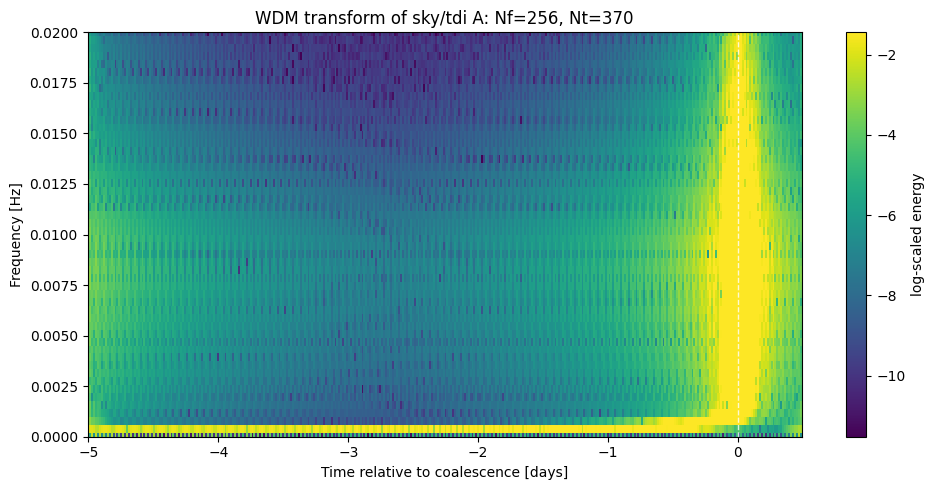

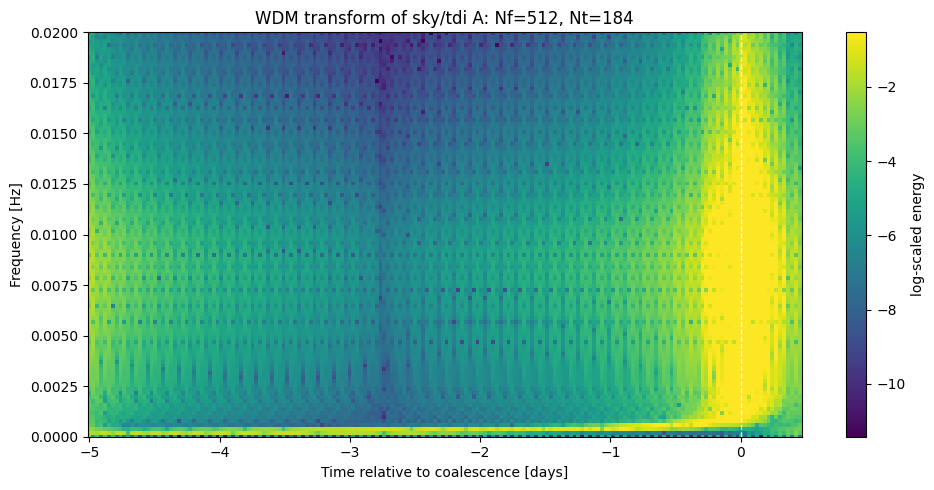

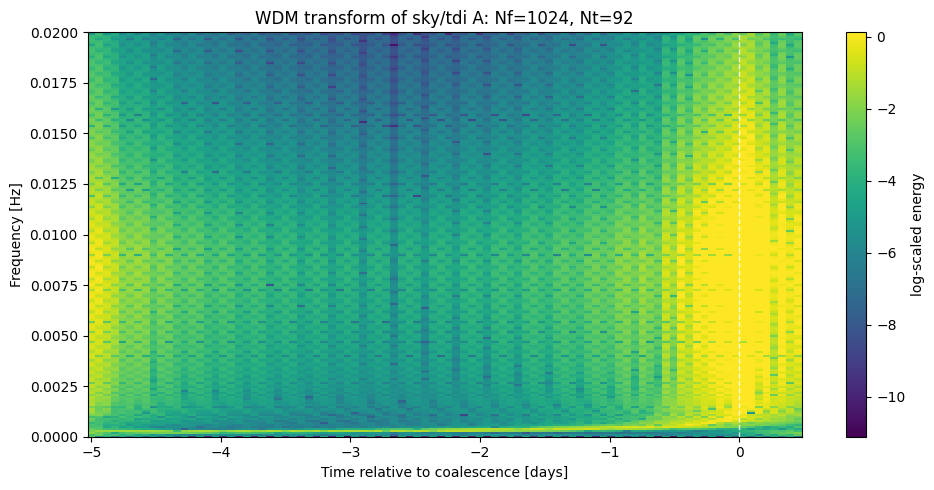

,Nf,Nt,samples_used,duration_days
0,256,370,94720,5.481481
1,512,184,94208,5.451852
2,1024,92,94208,5.451852


In [7]:
wdm_records = []
n_freq_candidates = [256, 512, 1024]

for n_freq in n_freq_candidates:
    wdm_data, n_time = crop_to_wdm_shape(data_crop, n_freq)
    wave = transform_wavelet_freq_time(wdm_data, n_freq, n_time)
    energy = np.log10(np.abs(wave).T + 1e-12)

    t_axis = np.linspace(time_crop_days[0], time_crop_days[0] + len(wdm_data) * dt / 86400, n_time)
    f_axis = np.linspace(0, 0.5 / dt, n_freq)

    plot_pcolormesh(
        t_axis,
        f_axis,
        energy,
        title=f'WDM transform of sky/tdi A: Nf={n_freq}, Nt={n_time}',
        xlabel='Time relative to coalescence [days]',
        ylabel='Frequency [Hz]',
    )
    plt.ylim(0, 0.02)
    plt.axvline(0, color='white', lw=1.0, ls='--', alpha=0.8)
    save_current_figure(FIGURE_DIR / f'04_wdm_sky_a_nfreq_{n_freq}.png')
    plt.show()

    wdm_records.append({'Nf': n_freq, 'Nt': n_time, 'samples_used': len(wdm_data), 'duration_days': len(wdm_data) * dt / 86400})

pd.DataFrame(wdm_records)

## 7. Fractional Fourier Transform

For FRFT, we use a shorter real-data segment near coalescence so the alpha scan remains fast and clear. This is still the real HDF5 signal, not simulated data.

FRFT segment samples: 8192
FRFT segment relative days: -0.37407316989886263 0.09994303380484107


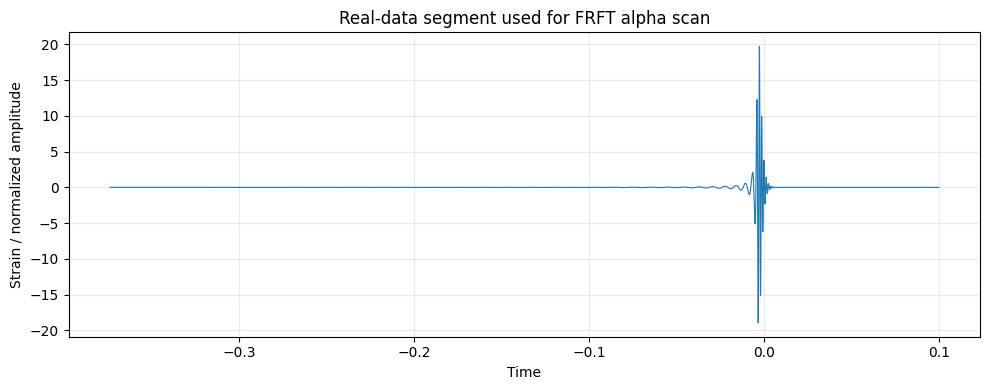

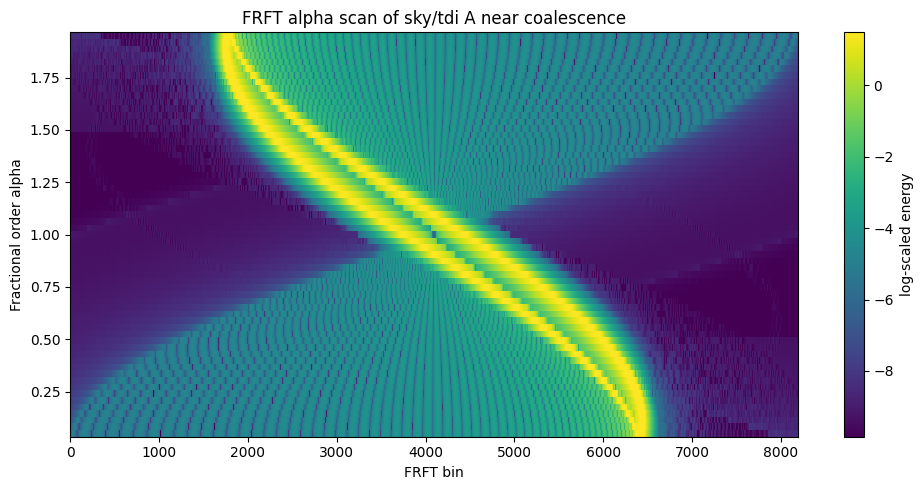

In [8]:
frft_points = 8192
frft_end_index = np.searchsorted(time_crop, coalescence_time + 0.1 * 86400)
frft_start_index = max(0, frft_end_index - frft_points)
frft_segment = clean_timeseries(data_crop[frft_start_index:frft_start_index + frft_points], normalize=True)
frft_time = time_crop_days[frft_start_index:frft_start_index + frft_points]

print('FRFT segment samples:', len(frft_segment))
print('FRFT segment relative days:', frft_time[0], frft_time[-1])

plot_timeseries(frft_time, frft_segment, 'Real-data segment used for FRFT alpha scan')
save_current_figure(FIGURE_DIR / '05_frft_input_segment.png')
plt.show()

alphas = np.linspace(0.05, 1.95, 61)
frft_energy = scan_frft_alpha(frft_segment, alphas)
frft_log = np.log10(frft_energy + 1e-12)
bins = np.arange(frft_log.shape[1])

plot_pcolormesh(
    bins,
    alphas,
    frft_log,
    title='FRFT alpha scan of sky/tdi A near coalescence',
    xlabel='FRFT bin',
    ylabel='Fractional order alpha',
)
save_current_figure(FIGURE_DIR / '06_frft_alpha_scan.png')
plt.show()

## 8. Summary

- The notebook reads the real file `E:\\BaiduNetdiskDownload\\LDC2_spritz_mbhb1_training_v1.h5` with `h5py`.
- HDF5 structure and metadata are printed directly from the file.
- NaN values in the observed TDI channels are counted and replaced with zero before analysis.
- The main visualization uses the real `sky/tdi` A channel because it exposes the MBHB signal feature more clearly than the noisy observed stream.
- WDM figures are generated for `Nf = 256, 512, 1024`, with the low-frequency band emphasized.
- FRFT uses a real-data segment near coalescence and scans fractional orders from 0.05 to 1.95.
- All figures are saved to `figures/task5_subtask1/`.